# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
# Load data and inspect
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df = pd.read_csv("loan_data.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


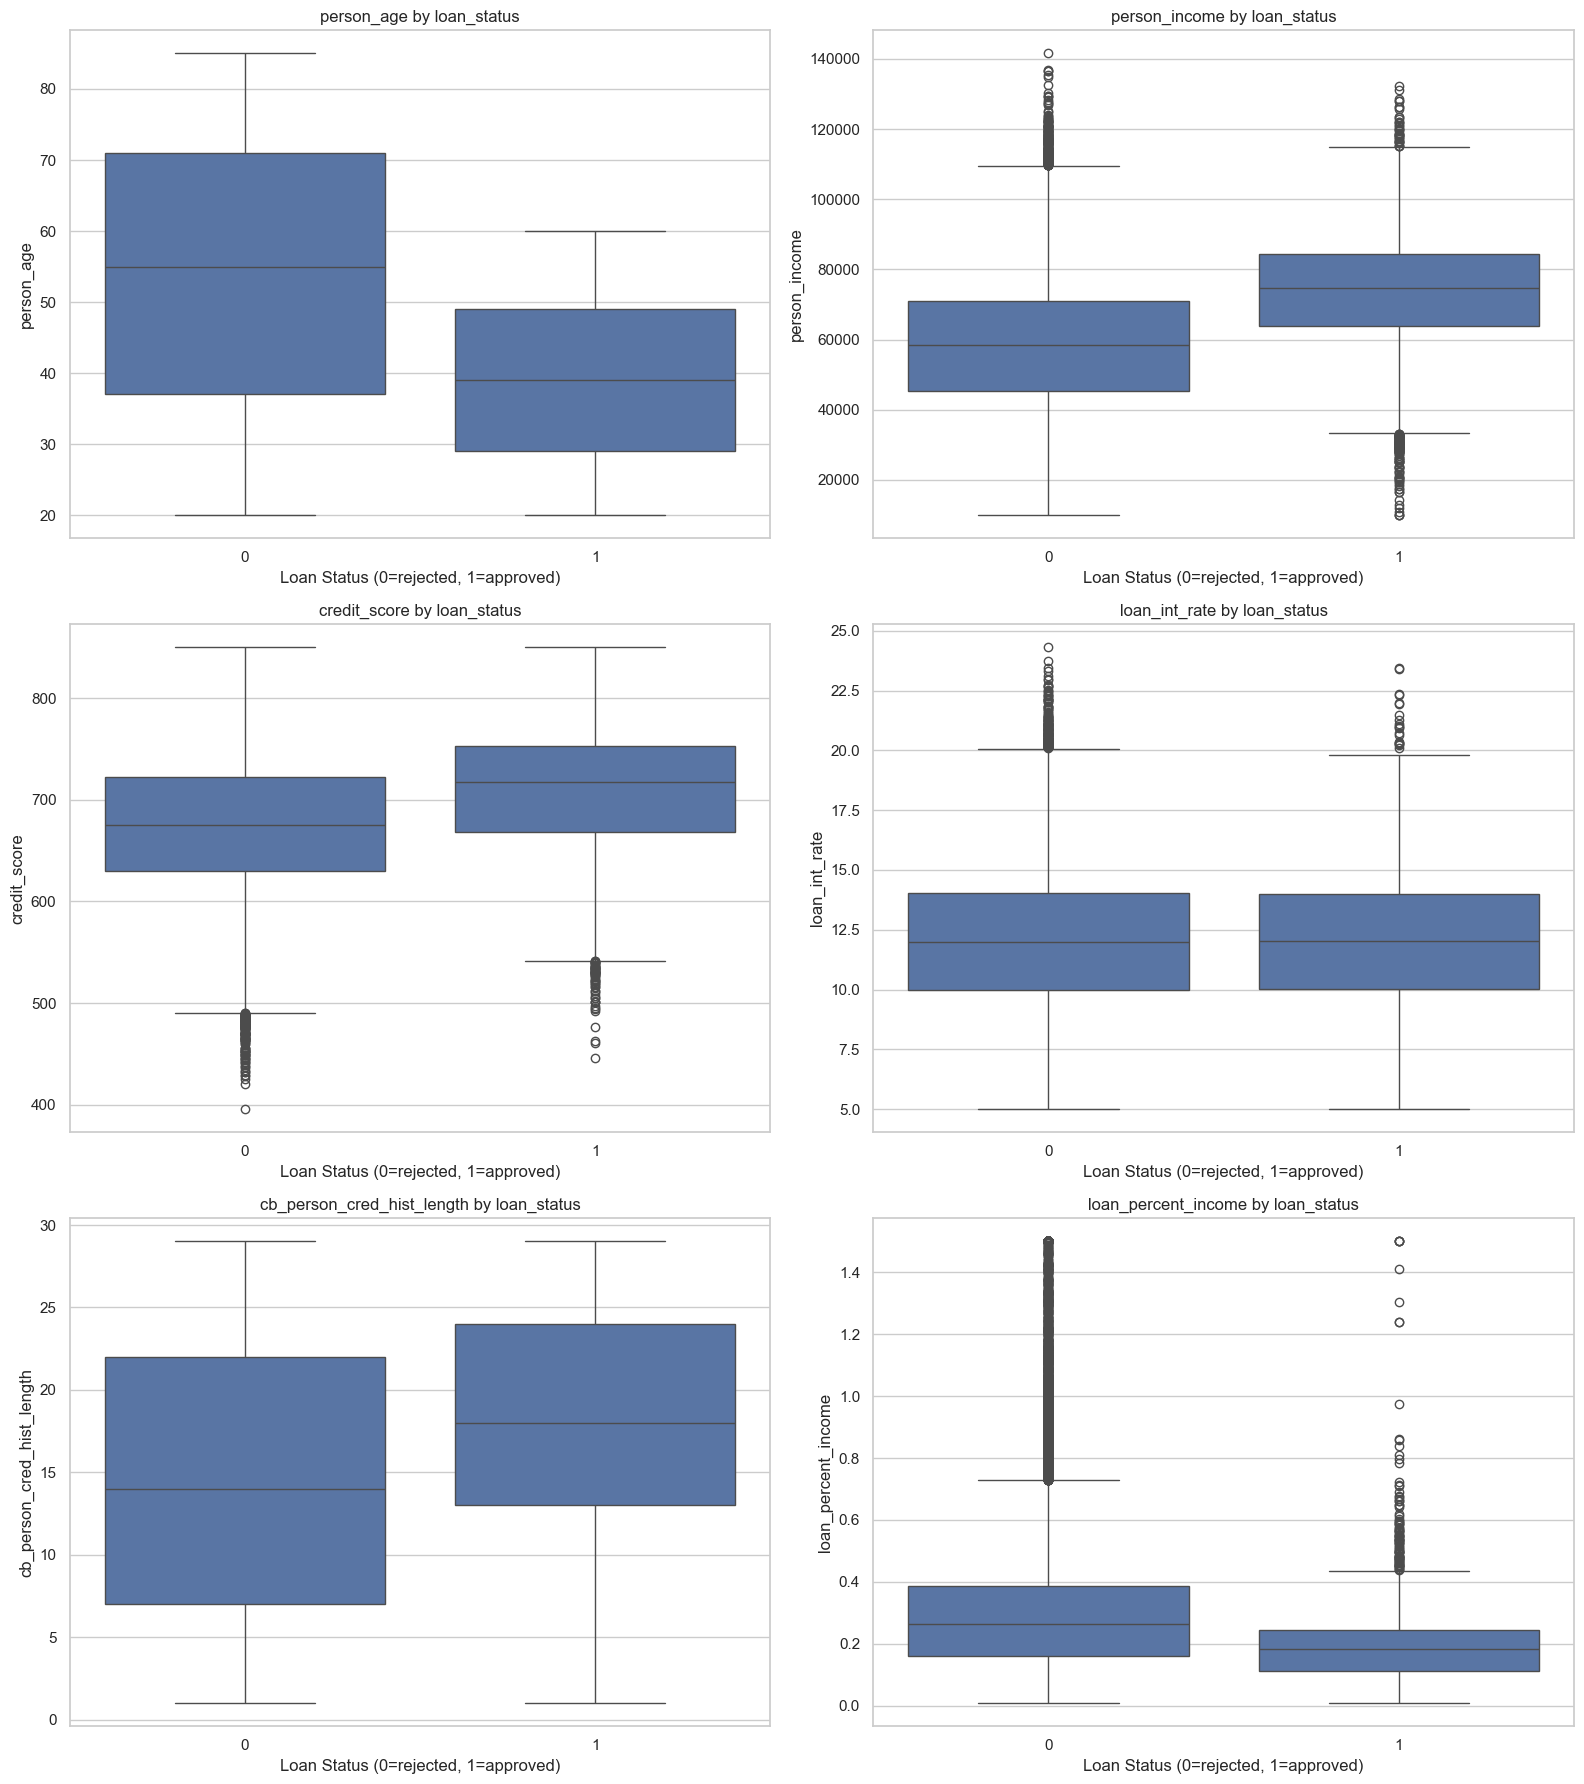

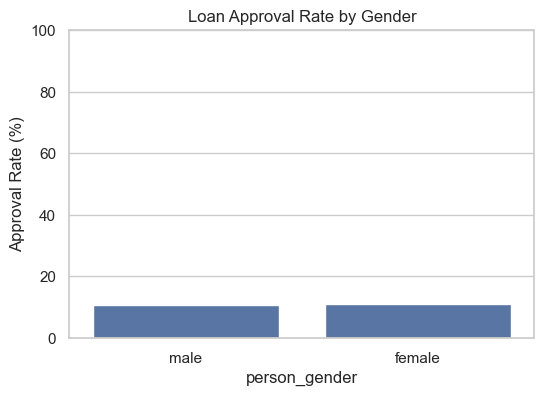

In [ ]:
# Quantitative comparisons (boxplots) for features vs loan_status
sns.set_theme(style="whitegrid", context="talk")

quant_vars = [
    "person_age",
    "person_income",
    "credit_score",
    "loan_int_rate",
    "cb_person_cred_hist_length",
    "loan_percent_income",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
for ax, var in zip(axes, quant_vars):
    sns.boxplot(
        x="loan_status",
        y=var,
        data=df,
        ax=ax,
        showfliers=False,
        palette=["#4C78A8", "#F58518"],
        width=0.55,
    )
    ax.set_title(f"{var.replace('_', ' ').title()} by Loan Status", fontsize=14)
    ax.set_xlabel("")
    ax.set_xticklabels(["Rejected", "Approved"])

fig.suptitle("Quantitative Features vs. Loan Outcome", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Compare approval rate by gender (categorical)
approval_by_gender = (
    df.groupby("person_gender", dropna=False)["loan_status"].mean().reset_index()
)
approval_by_gender["loan_status"] = approval_by_gender["loan_status"] * 100

plt.figure(figsize=(6, 5))
order = approval_by_gender.sort_values("loan_status")["person_gender"]
sns.barplot(
    x="person_gender",
    y="loan_status",
    data=approval_by_gender,
    order=order,
    palette=["#4C78A8", "#F58518"],
)
plt.ylabel("Approval Rate (%)")
plt.title("Loan Approval Rate by Gender", fontsize=16)
plt.ylim(0, approval_by_gender["loan_status"].max() * 1.12)

for i, row in approval_by_gender.iterrows():
    plt.text(i, row["loan_status"] + 0.5, f"{row['loan_status']:.1f}%", ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

## Observations & Potential Fairness Concerns

- **Age:** The boxplots show whether approved applicants tend to be older/younger. If the distribution of ages for approved vs rejected is notably different, that could indicate age is influencing the model.
- **Gender:** The approval rate bar chart allows us to see whether one gender is approved at a higher rate than another. A substantial gap could raise fair lending concerns.
- **Income, Credit Score, Interest Rate, Credit History Length, & Loan % of Income:** These are key quantitative variables that often drive credit decisions. Strong separation between approved vs rejected groups in these boxplots suggests the model is using them to decide approvals. Little overlap or large shifts in medians are evidence they are strong predictors.

Use these visualizations to support conclusions about which features are driving the model and whether there are indicators of discriminatory behavior. If age or gender appear to be linked to approval status beyond what is explained by bona fide factors (income, credit score, etc.), the institution should investigate further.

In [5]:
# Quantitative summaries to support interpretations
summary = df.groupby("loan_status")[
    [
        "person_age",
        "person_income",
        "credit_score",
        "loan_int_rate",
        "cb_person_cred_hist_length",
        "loan_percent_income",
    ]
].agg(["mean", "median", "std"]).T

print("=== Summary statistics by loan_status ===")
print(summary)

approval_by_gender = df.groupby("person_gender")["loan_status"].agg(["count", "mean"]).rename(columns={"mean": "approval_rate"})
approval_by_gender["approval_rate"] = approval_by_gender["approval_rate"] * 100

print("\n=== Approval rate by gender ===")
print(approval_by_gender)

=== Summary statistics by loan_status ===
loan_status                                   0             1
person_age                 mean       54.021318     39.482117
                           median     55.000000     39.000000
                           std        19.205607     11.783753
person_income              mean    58528.531356  73514.758800
                           median  58519.753892  74654.580855
                           std     19475.151323  17739.062377
credit_score               mean      676.202446    709.749597
                           median    675.642685    717.207593
                           std        69.295510     67.392747
loan_int_rate              mean       12.002137     12.009495
                           median     11.982008     12.018102
                           std         2.966163      2.946398
cb_person_cred_hist_length mean       14.669210     17.942980
                           median     14.000000     18.000000
                           s

## Summary: What Seems to Drive Decisions (and What Does Not)

- **Strong drivers of approval:** Income, credit score, credit history length, and loan percentage of income all show clear differences between approved and rejected groups. Approved applicants tend to have higher incomes, higher credit scores, longer credit histories, and lower loan percent income.
- **Age:** Approved applicants appear to be younger on average (median ~39 vs ~55). This suggests age correlates with the decision, but it may be an indirect effect (e.g., younger people in this dataset also having higher credit scores or incomes). Still, since age is a protected attribute, it is worth investigating whether it is used directly or via proxy features.
- **Interest rate:** The distributions of loan interest rate are nearly identical for approved and rejected groups, implying it is not a strong driver of approval in this dataset.
- **Gender:** Approval rates are very similar between male and female applicants (~10.8% vs ~11.0%). That suggests no strong direct gender bias in approvals, though a deeper fairness audit (e.g., intersectional analysis, other protected groups) is still recommended.

### Should the institution be concerned about legal trouble?
- The model appears to rely heavily on legitimate credit-related factors (income, credit score, credit history length) which are standard in lending decisions.
- However, the apparent age difference in approval outcomes is a potential concern because age is a protected characteristic. Even if the model does not explicitly use age, it could be indirectly using age via correlated features (proxy discrimination).

